# System-Level Simulations

This notebook demonstrates how to perform system-level simulations with Sionna 
by integrating key functionalities from the SYS and PHY modules, including: 
- Base station placement on a a hexagonal spiral grid
- User drop within each sector
- 3GPP-compliant channel generation
- Proportional fair scheduler
- Power control
- Link adaptation for adaptive modulation and coding scheme (MCS) selection
- Post-equalization signal-to-interference-plus-noise (SINR) computation
- Physical layer abstraction

Below is the diagram flow underlying the system-level simulator we will
build in this notebook.

This is an advanced notebook. We recommend first exploring the tutorials on 
[physical layer abstraction](https://nvlabs.github.io/sionna/sys/tutorials/notebooks/PHY_Abstraction.html), [link
adaptation](https://nvlabs.github.io/sionna/sys/tutorials/notebooks/LinkAdaptation.html), and [scheduling](https://nvlabs.github.io/sionna/sys/tutorials/notebooks/Scheduling.html).

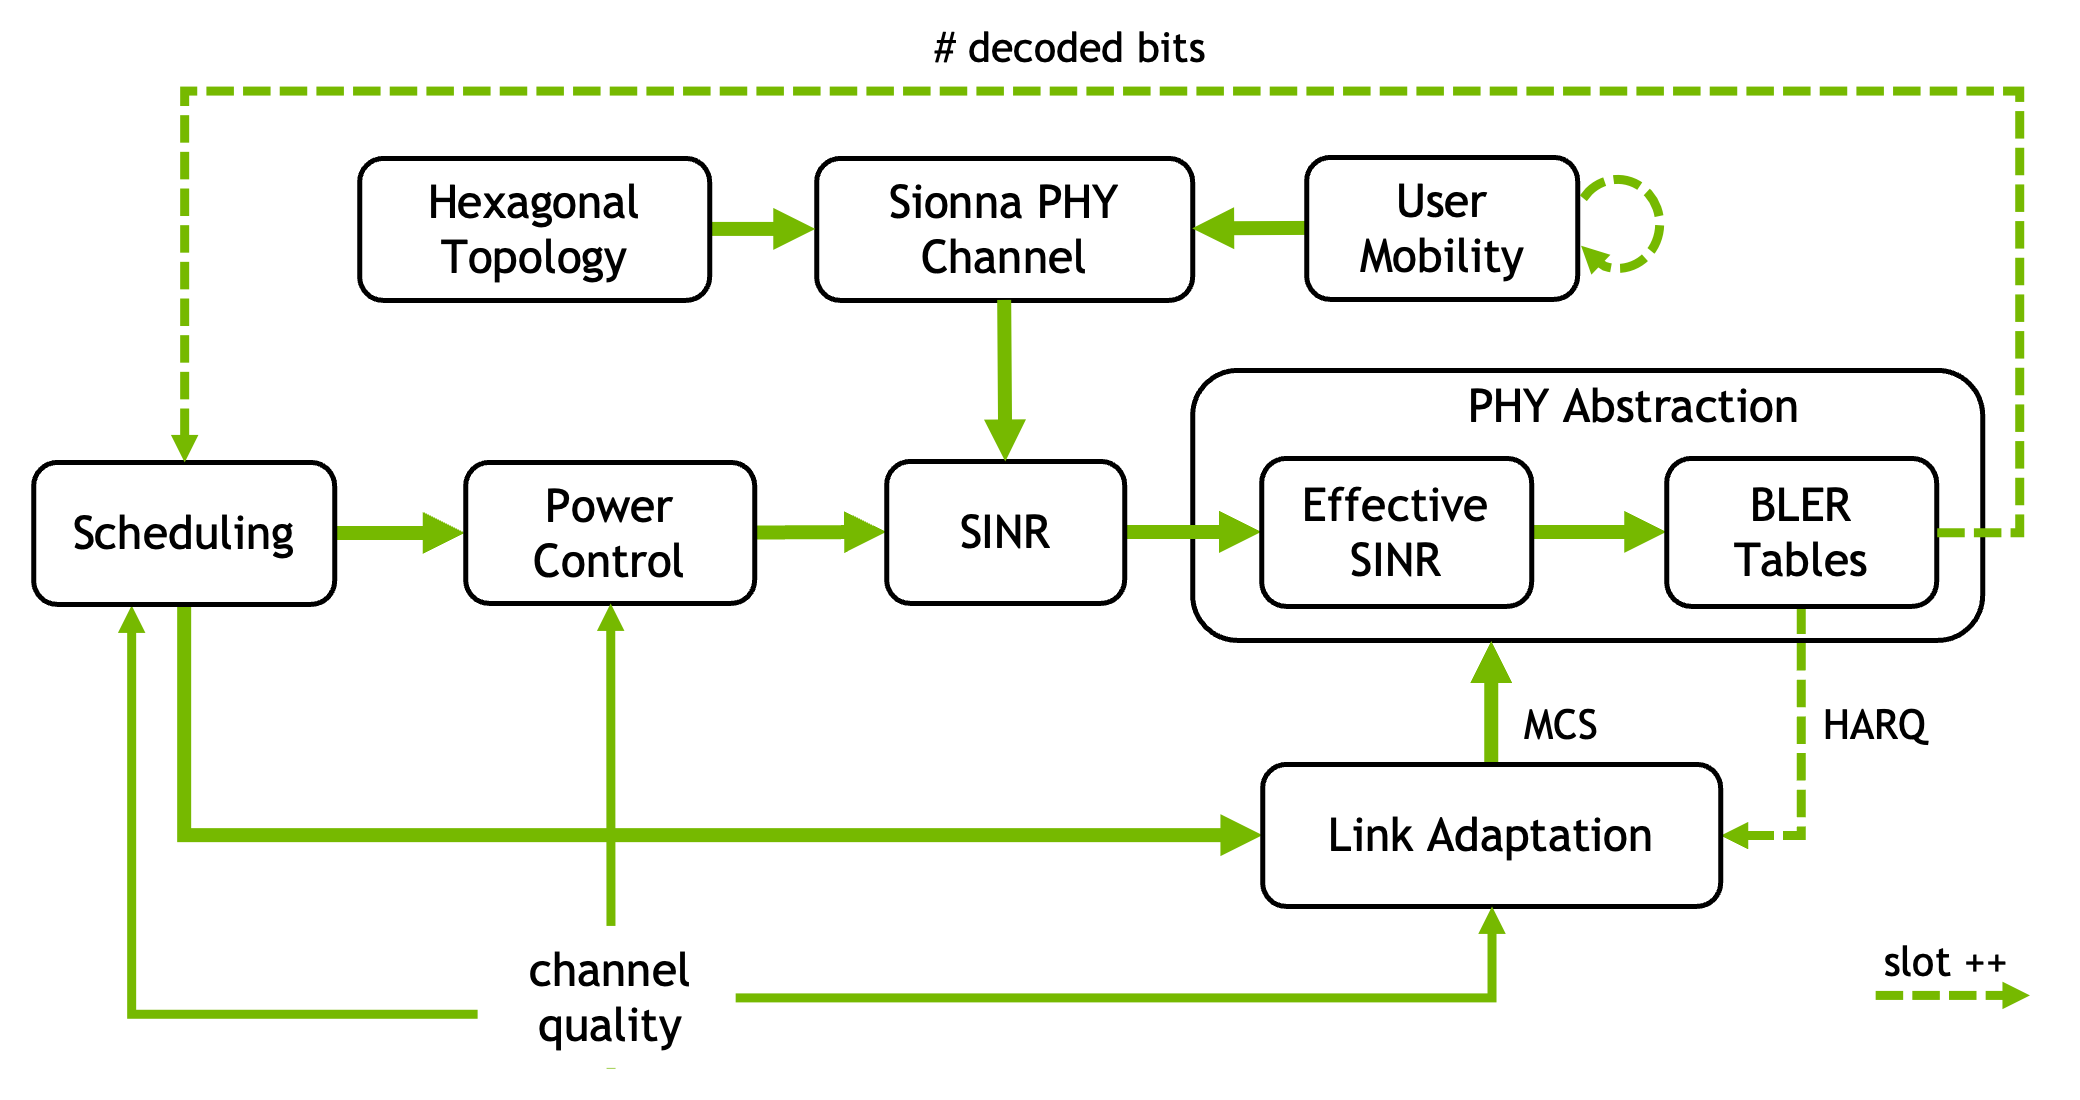

## Imports

We start by importing Sionna and the relevant external libraries:

In [1]:
# Import Sionna
try:
    import sionna.sys
except ImportError as e:
    import sys
    import os
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import torch

In [2]:
# Additional external libraries
import matplotlib.pyplot as plt
import numpy as np

# Sionna components
from sionna.sys.utils import spread_across_subcarriers
from sionna.sys import PHYAbstraction, \
    OuterLoopLinkAdaptation, gen_hexgrid_topology, \
    get_pathloss, open_loop_uplink_power_control, downlink_fair_power_control, \
    get_num_hex_in_grid, PFSchedulerSUMIMO
from sionna.phy.constants import BOLTZMANN_CONSTANT
from sionna.phy.utils import db_to_lin, dbm_to_watt, insert_dims
from sionna.phy import config, dtypes, Block
from sionna.phy.channel.tr38901 import UMi, UMa, RMa, PanelArray
from sionna.phy.channel import GenerateOFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, RZFPrecodedChannel, EyePrecodedChannel, \
    LMMSEPostEqualizationSINR

# Set random seed for reproducibility
sionna.phy.config.seed = 42

# Also set PyTorch and NumPy seeds for full reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Internal computational precision
sionna.phy.config.precision = 'single'  # 'single' or 'double'

## Utils

We will now define several auxiliary functions that are used in this notebook, including:
- Channel matrix evolution;
- User stream management;
- Signal-to-interference-plus-noise-ratio (SINR) computation;
- Achievable rate estimation.

### Channel matrix generation

We assume that channel matrix coefficients are regenerated from a specified 3GPP
model every `coherence_time` slots, following a typical block fading model.
For simplicity, we emulate the impact of fast fading by multiplying the channel
matrix by a factor that follows an autoregressive process evolving at each slot.

More realistic simulations would include channel evolution based on user
mobility in a ray-traced enviroment, as for example shown in
the notebook [Sionna SYS meets Sionna RT](https://nvlabs.github.io/sionna/sys/tutorials/notebooks/SYS_Meets_RT.html).

In [3]:
class ChannelMatrix(Block):
    def __init__(self,
                 resource_grid,
                 batch_size,
                 num_rx,
                 num_tx,
                 coherence_time,
                 precision=None,
                 device=None):
        super().__init__(precision=precision, device=device)
        self.resource_grid = resource_grid
        self.coherence_time = coherence_time
        self.batch_size = batch_size
        self.num_rx = num_rx
        self.num_tx = num_tx
        self._init_fading()

    def _init_fading(self):
        """Initialize/reset fading state tensors."""
        # Use register_buffer for torch.compile compatibility
        if not hasattr(self, '_rho_fading_initialized'):
            self.register_buffer(
                'rho_fading',
                torch.empty([self.batch_size, self.num_rx, self.num_tx],
                           dtype=self.dtype, device=self.device).uniform_(0.95, 0.99),
                persistent=False
            )
            self.register_buffer(
                'fading',
                torch.ones([self.batch_size, self.num_rx, self.num_tx],
                          dtype=self.dtype, device=self.device),
                persistent=False
            )
            self._rho_fading_initialized = True
        else:
            # Reset fading to ones
            self.fading.fill_(1.0)

    def reset(self):
        """Reset the fading state for a new simulation."""
        self._init_fading()

    def __call__(self, channel_model):
        """Override __call__ to avoid converting channel_model to tensor."""
        return self.call(channel_model)

    def call(self, channel_model):
        """Generate OFDM channel matrix."""
        ofdm_channel = GenerateOFDMChannel(channel_model, self.resource_grid)
        h_freq = ofdm_channel(self.batch_size)
        return h_freq

    def update(self, channel_model, h_freq, slot):
        """Update channel matrix every coherence_time slots."""
        h_freq_new = self.call(channel_model)
        change = ((slot % self.coherence_time) == 0)
        if change:
            h_freq = h_freq_new
        return h_freq

    def apply_fading(self, h_freq):
        """Apply fading, modeled as an autoregressive process, to channel matrix."""
        noise = torch.empty_like(self.fading).uniform_(-0.1, 0.1)
        new_fading = 1.0 - self.rho_fading + self.rho_fading * self.fading + noise
        new_fading = torch.clamp(new_fading, min=1e-6)  # Prevent exactly zero fading
        self.fading.copy_(new_fading)
        
        fading_expand = insert_dims(self.fading, 1, axis=2)
        fading_expand = insert_dims(fading_expand, 3, axis=4)
        h_freq_fading = torch.sqrt(fading_expand).to(self.cdtype) * h_freq
        return h_freq_fading


### User stream management

The
[StreamManagement](https://nvlabs.github.io/sionna/phy/api/mimo/stream_management.html)
class configures which base station serves which user.  
We assume here for
simplicity that each receiver is associated with the nearest base station.

In [4]:
def get_stream_management(direction,
                          num_rx,
                          num_tx,
                          num_streams_per_ut,
                          num_ut_per_sector):
    """
    Instantiate a StreamManagement object.
    It determines which data streams are intended for each receiver
    """
    if direction == 'downlink':
        num_streams_per_tx = num_streams_per_ut * num_ut_per_sector
        # RX-TX association matrix
        rx_tx_association = np.zeros([num_rx, num_tx])
        idx = np.array([[i1, i2] for i2 in range(num_tx) for i1 in
                        np.arange(i2*num_ut_per_sector,
                                  (i2+1)*num_ut_per_sector)])
        rx_tx_association[idx[:, 0], idx[:, 1]] = 1

    else:
        num_streams_per_tx = num_streams_per_ut
        # RX-TX association matrix
        rx_tx_association = np.zeros([num_rx, num_tx])
        idx = np.array([[i1, i2] for i1 in range(num_rx) for i2 in
                        np.arange(i1*num_ut_per_sector,
                                  (i1+1)*num_ut_per_sector)])
        rx_tx_association[idx[:, 0], idx[:, 1]] = 1

    stream_management = StreamManagement(
        rx_tx_association, num_streams_per_tx)
    return stream_management

### SINR computation

Computing the signal-to-noise-plus-interference-ratio (SINR) is
the first step to determine the block error rate (BLER) and, eventually, the user
throughput, via the physical layer abstraction.

In [5]:
def get_sinr(tx_power,
             stream_management,
             no,
             direction,
             h_freq_fading,
             num_bs,
             num_ut_per_sector,
             num_streams_per_ut,
             resource_grid):
    """ Compute post-equalization SINR. It is assumed:
     - DL: Regularized zero-forcing precoding
     - UL: No precoding, only power allocation
    LMMSE equalizer is used in both DL and UL.
    """
    # tx_power: [batch_size, num_bs, num_tx_per_sector,
    #            num_streams_per_tx, num_ofdm_sym, num_subcarriers]
    # Flatten across sectors
    # [batch_size, num_tx, num_streams_per_tx, num_ofdm_symbols, num_subcarriers]
    s = tx_power.shape
    tx_power = torch.reshape(tx_power, [s[0], s[1]*s[2]] + list(s[3:]))

    # Compute SINR
    # [batch_size, num_ofdm_sym, num_subcarriers, num_ut,
    #  num_streams_per_ut]
    if direction == 'downlink':
        # Regularized zero-forcing precoding in the DL
        precoded_channel = RZFPrecodedChannel(resource_grid=resource_grid,
                                              stream_management=stream_management)
        h_eff = precoded_channel(h_freq_fading,
                                 tx_power=tx_power,
                                 alpha=no)  # Regularizer
    else:
        # No precoding in the UL: just power allocation
        precoded_channel = EyePrecodedChannel(resource_grid=resource_grid,
                                              stream_management=stream_management)
        h_eff = precoded_channel(h_freq_fading,
                                 tx_power=tx_power)

    # LMMSE equalizer
    lmmse_posteq_sinr = LMMSEPostEqualizationSINR(resource_grid=resource_grid,
                                                  stream_management=stream_management)
    # Post-equalization SINR
    # [batch_size, num_ofdm_symbols, num_subcarriers, num_rx, num_streams_per_rx]
    sinr = lmmse_posteq_sinr(h_eff, no=no, interference_whitening=True)

    # [batch_size, num_ofdm_symbols, num_subcarriers, num_ut, num_streams_per_ut]
    sinr = torch.reshape(
        sinr, list(sinr.shape[:-2]) + [num_bs*num_ut_per_sector, num_streams_per_ut])

    # Regroup by sector
    # [batch_size, num_ofdm_symbols, num_subcarriers, num_bs, num_ut_per_sector, num_streams_per_ut]
    sinr = torch.reshape(
        sinr, list(sinr.shape[:-2]) + [num_bs, num_ut_per_sector, num_streams_per_ut])

    # [batch_size, num_bs, num_ofdm_sym, num_subcarriers, num_ut_per_sector, num_streams_per_ut]
    sinr = torch.permute(sinr, [0, 3, 1, 2, 4, 5])
    return sinr

### Estimation of Achievable Rate

To fairly allocate users to the appropriate time and frequency resources, the
proportional fairness (PF) scheduler must first estimate the *achievable* rate for
each user.

Users are then ranked based on the ratio of their achievable rate to
their *achieved* rate, called PF metric.  

Here, we assume that the achievable rate is estimated using the Shannon capacity
based on the effective SINR.  
The rate estimation is thus uniform across subcarriers, resulting in only one
user being scheduled per slot.

In [6]:
def estimate_achievable_rate(sinr_eff_db_last,
                             num_ofdm_sym,
                             num_subcarriers):
    """ Estimate achievable rate """
    # [batch_size, num_bs, num_ut_per_sector]
    rate_achievable_est = torch.log2(torch.tensor(1.0, dtype=sinr_eff_db_last.dtype) +
                                     db_to_lin(sinr_eff_db_last))

    # Broadcast to time/frequency grid
    # [batch_size, num_bs, num_ofdm_sym, num_subcarriers, num_ut_per_sector]
    rate_achievable_est = insert_dims(
        rate_achievable_est, 2, axis=-2)
    rate_achievable_est = torch.tile(rate_achievable_est,
                                     [1, 1, num_ofdm_sym, num_subcarriers, 1])
    return rate_achievable_est

### Result recording

We record the relevant metrics in a dictionary for further analysis, including:
- Number of decoded bits;
- HARQ feedback;
- MCS index;
- Effective SINR;
- Pathloss of serving cell;
- Number of allocated REs;
- Proportional fairness (PF) metric;
- Transmit power;
- Outer-loop link adaptation (OLLA) offset.


In [7]:
class TensorList:
    """A simple TensorArray-like class for accumulating tensors.
    
    Pre-allocates storage to avoid dynamic list operations that
    cause recompilation in torch.compile.
    """
    def __init__(self, size, element_shape, dtype=torch.float32, device=None):
        self.size = size
        self.element_shape = element_shape
        self.dtype = dtype
        # Pre-allocate tensor storage to avoid dynamic list growth
        # which causes recompilation in torch.compile
        self.data = torch.zeros([size] + list(element_shape), dtype=dtype, device=device)
    
    def write(self, index, value):
        """Write a value at the given index using tensor indexing."""
        # Direct tensor indexing - no dynamic Python operations
        self.data[index] = value
        return self
    
    def stack(self):
        """Return the pre-allocated tensor."""
        return self.data


def init_result_history(batch_size,
                        num_slots,
                        num_bs,
                        num_ut_per_sector,
                        device=None):
    """ Initialize dictionary containing history of results """
    hist = {}
    for key in ['pathloss_serving_cell',
                'tx_power', 'olla_offset',
                'sinr_eff', 'pf_metric',
                'num_decoded_bits', 'mcs_index',
                'harq', 'num_allocated_re']:
        hist[key] = TensorList(
            size=num_slots,
            element_shape=[batch_size,
                           num_bs,
                           num_ut_per_sector],
            dtype=torch.float32,
            device=device)
    return hist


def record_results(hist,
                   slot,
                   sim_failed=False,
                   pathloss_serving_cell=None,
                   num_allocated_re=None,
                   tx_power_per_ut=None,
                   num_decoded_bits=None,
                   mcs_index=None,
                   harq_feedback=None,
                   olla_offset=None,
                   sinr_eff=None,
                   pf_metric=None,
                   shape=None):
    """ Record results of last slot """
    if not sim_failed:
        for key, value in zip(['pathloss_serving_cell', 'olla_offset', 'sinr_eff',
                               'num_allocated_re', 'tx_power', 'num_decoded_bits',
                               'mcs_index', 'harq'],
                              [pathloss_serving_cell, olla_offset, sinr_eff,
                               num_allocated_re, tx_power_per_ut, num_decoded_bits,
                               mcs_index, harq_feedback]):
            hist[key] = hist[key].write(slot, value.float())
        # Average PF metric across resources
        hist['pf_metric'] = hist['pf_metric'].write(
            slot, torch.mean(pf_metric, dim=[-2, -3]))
    else:
        nan_tensor = torch.full(shape, float('nan'), dtype=torch.float32)
        for key in hist:
            hist[key] = hist[key].write(slot, nan_tensor)
    return hist


def clean_hist(hist, batch=0):
    """ Extract batch, convert to Numpy, and mask metrics when user is not
    scheduled """
    # Extract batch and convert to Numpy
    for key in hist:
        if isinstance(hist[key], TensorList):
            # Stack and convert to numpy
            tensor = hist[key].stack()
            if hasattr(tensor, 'cpu'):
                tensor = tensor.cpu()
            # [num_slots, num_bs, num_ut_per_sector]
            hist[key] = tensor.numpy()[:, batch, :, :]
        elif isinstance(hist[key], torch.Tensor):
            if hasattr(hist[key], 'cpu'):
                hist[key] = hist[key].cpu()
            hist[key] = hist[key].numpy()[:, batch, :, :]

    # Mask metrics when user is not scheduled
    hist['mcs_index'] = np.where(
        hist['harq'] == -1, np.nan, hist['mcs_index'])
    hist['sinr_eff'] = np.where(
        hist['harq'] == -1, np.nan, hist['sinr_eff'])
    hist['tx_power'] = np.where(
        hist['harq'] == -1, np.nan, hist['tx_power'])
    hist['num_allocated_re'] = np.where(
        hist['harq'] == -1, 0, hist['num_allocated_re'])
    hist['harq'] = np.where(
        hist['harq'] == -1, np.nan, hist['harq'])
    return hist

## Simulation

We now put everything together and create a system-level simulator Sionna block.
We will then demonstrate how to instantiate it and run simulations. 

### Sionna block

We next define a compound Sionna block called `SystemLevelSimulator` composed of multiple submodules.  
It is structured as follows:
- `__init__` method, which initializes the main modules, including:
    - 3GPP channel model;
    - Multicell topology and user drop
    - Stream management;
    - Physical layer abstraction;
    - Scheduler;
    - Link adaptation;
    - Channel matrix (moved here for `torch.compile` compatibility)
- `call` method, which loops over slots and performs:
    - Channel generation;
    - Channel estimation, assumed ideal;
    - User scheduling;
    - Power control;
    - Per-stream SINR computation;
    - Physical layer abstraction;
    - User mobility.

The `call` method is decorated with `@torch.compile` for optimized performance. The code has been structured to be compilation-friendly by:
- Moving object creation to `__init__`
- Using registered buffers with in-place updates for stateful modules
- Pre-computing values that would cause graph breaks
- Ensuring all tensors are created on the correct device


In [8]:
class SystemLevelSimulator(Block):
    def __init__(self,
                 batch_size,
                 num_rings,
                 num_ut_per_sector,
                 carrier_frequency,
                 resource_grid,
                 scenario,
                 direction,
                 ut_array,
                 bs_array,
                 bs_max_power_dbm,
                 ut_max_power_dbm,
                 coherence_time,
                 pf_beta=0.98,
                 max_bs_ut_dist=None,
                 min_bs_ut_dist=None,
                 temperature=294,
                 o2i_model='low',
                 average_street_width=20.0,
                 average_building_height=5.0,
                 precision=None):
        super().__init__(precision=precision)

        assert scenario in ['umi', 'uma', 'rma']
        assert direction in ['uplink', 'downlink']
        self.scenario = scenario
        self.batch_size = int(batch_size)
        self.resource_grid = resource_grid
        self.num_ut_per_sector = int(num_ut_per_sector)
        self.direction = direction
        self.bs_max_power_dbm = bs_max_power_dbm
        self.ut_max_power_dbm = ut_max_power_dbm
        self.coherence_time = int(coherence_time)
        num_cells = get_num_hex_in_grid(num_rings)
        self.num_bs = num_cells * 3
        self.num_ut = self.num_bs * self.num_ut_per_sector
        self.num_ut_ant = ut_array.num_ant
        self.num_bs_ant = bs_array.num_ant
        if bs_array.polarization == 'dual':
            self.num_bs_ant *= 2
        if self.direction == 'uplink':
            self.num_tx, self.num_rx = self.num_ut, self.num_bs
            self.num_tx_ant, self.num_rx_ant = self.num_ut_ant, self.num_bs_ant
            self.num_tx_per_sector = self.num_ut_per_sector
        else:
            self.num_tx, self.num_rx = self.num_bs, self.num_ut
            self.num_tx_ant, self.num_rx_ant = self.num_bs_ant, self.num_ut_ant
            self.num_tx_per_sector = 1

        self.num_streams_per_ut = resource_grid.num_streams_per_tx
        
        # Pre-compute for torch.compile compatibility
        self._mcs_category = 1 if direction == 'downlink' else 0

        self.stream_management = get_stream_management(direction,
                                                       self.num_rx,
                                                       self.num_tx,
                                                       self.num_streams_per_ut,
                                                       num_ut_per_sector)
        self.no = torch.tensor(BOLTZMANN_CONSTANT * temperature *
                               resource_grid.subcarrier_spacing,
                               dtype=self.dtype, device=self.device)

        self.slot_duration = resource_grid.ofdm_symbol_duration * \
            resource_grid.num_ofdm_symbols

        self._setup_channel_model(
            scenario, carrier_frequency, o2i_model, ut_array, bs_array,
            average_street_width, average_building_height)

        self._setup_topology(num_rings, min_bs_ut_dist, max_bs_ut_dist)

        self.phy_abs = PHYAbstraction(precision=self.precision, device=self.device)

        self.olla = OuterLoopLinkAdaptation(
            self.phy_abs,
            self.num_ut_per_sector,
            batch_size=[self.batch_size, self.num_bs],
            precision=self.precision,
            device=self.device)

        self.scheduler = PFSchedulerSUMIMO(
            self.num_ut_per_sector,
            resource_grid.fft_size,
            resource_grid.num_ofdm_symbols,
            batch_size=[self.batch_size, self.num_bs],
            num_streams_per_ut=self.num_streams_per_ut,
            beta=pf_beta,
            precision=self.precision,
            device=self.device)

        # Create ChannelMatrix in __init__ for torch.compile compatibility
        self.channel_matrix = ChannelMatrix(
            self.resource_grid,
            self.batch_size,
            self.num_rx,
            self.num_tx,
            self.coherence_time,
            precision=self.precision,
            device=self.device)
        
        # Pre-allocate rx_tx_association tensor
        self._rx_tx_association = torch.tensor(
            self.stream_management.rx_tx_association,
            device=self.device)

    def _setup_channel_model(self, scenario, carrier_frequency, o2i_model,
                             ut_array, bs_array, average_street_width,
                             average_building_height):
        common_params = {
            'carrier_frequency': carrier_frequency,
            'ut_array': ut_array,
            'bs_array': bs_array,
            'direction': self.direction,
            'enable_pathloss': True,
            'enable_shadow_fading': True,
            'precision': self.precision
        }

        if scenario == 'umi':
            self.channel_model = UMi(o2i_model=o2i_model, **common_params)
        elif scenario == 'uma':
            self.channel_model = UMa(o2i_model=o2i_model, **common_params)
        elif scenario == 'rma':
            self.channel_model = RMa(
                average_street_width=average_street_width,
                average_building_height=average_building_height,
                **common_params)

    def _setup_topology(self, num_rings, min_bs_ut_dist, max_bs_ut_dist):
        self.ut_loc, self.bs_loc, self.ut_orientations, self.bs_orientations, \
            self.ut_velocities, self.in_state, self.los, self.bs_virtual_loc, self.grid = \
            gen_hexgrid_topology(
                batch_size=self.batch_size,
                num_rings=num_rings,
                num_ut_per_sector=self.num_ut_per_sector,
                min_bs_ut_dist=min_bs_ut_dist,
                max_bs_ut_dist=max_bs_ut_dist,
                scenario=self.scenario,
                los=True,
                return_grid=True,
                precision=self.precision)

        self.channel_model.set_topology(
            self.ut_loc, self.bs_loc, self.ut_orientations,
            self.bs_orientations, self.ut_velocities,
            self.in_state, self.los, self.bs_virtual_loc)

    def _reset_olla(self, bler_target, olla_delta_up):
        """Reset OLLA parameters - must be called OUTSIDE compiled code."""
        self.olla.reset()
        self.olla.bler_target = bler_target
        self.olla.delta_up = olla_delta_up

    def _init_feedback_tensors(self):
        """Initialize feedback tensors - can be called inside compiled code."""
        self.channel_matrix.reset()

        last_harq_feedback = -torch.ones(
            [self.batch_size, self.num_bs, self.num_ut_per_sector],
            dtype=torch.int32, device=self.device)

        sinr_eff_feedback = torch.ones(
            [self.batch_size, self.num_bs, self.num_ut_per_sector],
            dtype=self.dtype, device=self.device)

        num_decoded_bits = torch.zeros(
            [self.batch_size, self.num_bs, self.num_ut_per_sector],
            dtype=torch.int32, device=self.device)
        return last_harq_feedback, sinr_eff_feedback, num_decoded_bits

    def _group_by_sector(self, tensor):
        tensor = torch.reshape(tensor, [self.batch_size,
                                        self.num_bs,
                                        self.num_ut_per_sector,
                                        self.resource_grid.num_ofdm_symbols])
        return torch.permute(tensor, [0, 1, 3, 2])

    def call(self,
             num_slots,
             alpha_ul,
             p0_dbm_ul,
             bler_target,
             olla_delta_up,
             mcs_table_index=1,
             fairness_dl=0,
             guaranteed_power_ratio_dl=0.5):
        """Main entry point - resets OLLA then runs compiled simulation."""
        # Reset OLLA parameters OUTSIDE compiled code to avoid graph breaks
        self._reset_olla(bler_target, olla_delta_up)
        # Run compiled simulation
        return self._run_simulation(num_slots, alpha_ul, p0_dbm_ul,
                                    mcs_table_index, fairness_dl,
                                    guaranteed_power_ratio_dl)

    @torch.compile
    def _run_simulation(self,
                        num_slots,
                        alpha_ul,
                        p0_dbm_ul,
                        mcs_table_index=1,
                        fairness_dl=0,
                        guaranteed_power_ratio_dl=0.5):
        """Compiled simulation loop."""
        # Initialize result history
        hist = init_result_history(self.batch_size,
                                   num_slots,
                                   self.num_bs,
                                   self.num_ut_per_sector,
                                   device=self.device)

        # Initialize feedback tensors
        harq_feedback, sinr_eff_feedback, num_decoded_bits = \
            self._init_feedback_tensors()

        # Generate initial channel
        h_freq = self.channel_matrix(self.channel_model)

        # Simulation loop
        for slot in range(num_slots):
            # Channel update
            h_freq = self.channel_matrix.update(self.channel_model, h_freq, slot)
            h_freq_fading = self.channel_matrix.apply_fading(h_freq)

            # Scheduler
            rate_achievable_est = estimate_achievable_rate(
                self.olla.sinr_eff_db_last,
                self.resource_grid.num_ofdm_symbols,
                self.resource_grid.fft_size)

            is_scheduled = self.scheduler(num_decoded_bits, rate_achievable_est)

            num_allocated_sc = torch.minimum(
                torch.sum(is_scheduled.int(), dim=-1),
                torch.ones(1, dtype=torch.int32, device=self.device))
            num_allocated_sc = torch.sum(num_allocated_sc, dim=-2)
            num_allocated_re = torch.sum(is_scheduled.int(), dim=[-1, -3, -4])

            # Power control
            pathloss_all_pairs, pathloss_serving_cell = get_pathloss(
                h_freq_fading, rx_tx_association=self._rx_tx_association)
            pathloss_serving_cell = self._group_by_sector(pathloss_serving_cell)

            if self.direction == 'uplink':
                tx_power_per_ut = open_loop_uplink_power_control(
                    pathloss_serving_cell,
                    num_allocated_sc,
                    alpha=alpha_ul,
                    p0_dbm=p0_dbm_ul,
                    ut_max_power_dbm=self.ut_max_power_dbm)
            else:
                one = torch.ones(1, dtype=pathloss_serving_cell.dtype, device=self.device)
                rx_power_tot = torch.sum(one / pathloss_all_pairs, dim=-2)
                rx_power_tot = self._group_by_sector(rx_power_tot)
                interference_dl = rx_power_tot - one / pathloss_serving_cell
                interference_dl = interference_dl * dbm_to_watt(self.bs_max_power_dbm)

                tx_power_per_ut, _ = downlink_fair_power_control(
                    pathloss_serving_cell,
                    interference_dl + self.no,
                    num_allocated_sc,
                    bs_max_power_dbm=self.bs_max_power_dbm,
                    guaranteed_power_ratio=guaranteed_power_ratio_dl,
                    fairness=fairness_dl,
                    precision=self.precision)

            tx_power = spread_across_subcarriers(
                tx_power_per_ut,
                is_scheduled,
                num_tx=self.num_tx_per_sector,
                precision=self.precision)

            # Per-stream SINR
            sinr = get_sinr(tx_power,
                            self.stream_management,
                            self.no,
                            self.direction,
                            h_freq_fading,
                            self.num_bs,
                            self.num_ut_per_sector,
                            self.num_streams_per_ut,
                            self.resource_grid)

            # Link adaptation
            mcs_index = self.olla(num_allocated_re,
                                  harq_feedback=harq_feedback,
                                  sinr_eff=sinr_eff_feedback)

            # PHY abstraction
            num_decoded_bits, harq_feedback, sinr_eff, _, _ = self.phy_abs(
                mcs_index,
                sinr=sinr,
                mcs_table_index=mcs_table_index,
                mcs_category=self._mcs_category)

            # SINR feedback
            sinr_eff_feedback = torch.where(
                num_allocated_re > 0,
                sinr_eff,
                torch.zeros(1, dtype=self.dtype, device=self.device))

            # Record results
            hist = record_results(hist,
                                  slot,
                                  sim_failed=False,
                                  pathloss_serving_cell=torch.sum(pathloss_serving_cell, dim=-2),
                                  num_allocated_re=num_allocated_re,
                                  tx_power_per_ut=torch.sum(tx_power_per_ut, dim=-2),
                                  num_decoded_bits=num_decoded_bits,
                                  mcs_index=mcs_index,
                                  harq_feedback=harq_feedback,
                                  olla_offset=self.olla.offset,
                                  sinr_eff=sinr_eff,
                                  pf_metric=self.scheduler.pf_metric)

            # User mobility
            self.ut_loc = self.ut_loc + self.ut_velocities * self.slot_duration
            self.channel_model.set_topology(
                self.ut_loc, self.bs_loc, self.ut_orientations,
                self.bs_orientations, self.ut_velocities,
                self.in_state, self.los, self.bs_virtual_loc)

        for key in hist:
            hist[key] = hist[key].stack()
        return hist


### Scenario parameters

To initialize the system-level simulator, we must define the following parameters:
- 3GPP desidered scenario and the multicell grid;
- Communication direction (downlink or uplink);
- OFDM resource grid configuration;
- Modulation and coding scheme table;
- Transmit power for the base stations and user terminals;
- Antenna arrays at the base stations and user terminals.


In [9]:
# Communication direction
direction = 'downlink'  # 'uplink' or 'downlink'

# 3GPP scenario parameters
scenario = 'umi'  # 'umi', 'uma' or 'rma'

# Number of rings of the hexagonal grid
# With num_rings=1, 7*3=21 base stations are placed
num_rings = 1

# N. users per sector
num_ut_per_sector = 10

# Max/min distance between base station and served users
max_bs_ut_dist = 80  # [m]
min_bs_ut_dist = 0  # [m]

# Carrier frequency
carrier_frequency = 3.5e9  # [Hz]

# Transmit power for base station and user terminals
bs_max_power_dbm = 56  # [dBm]
ut_max_power_dbm = 26  # [dBm]

# Channel is regenerated every coherence_time slots
coherence_time = 100  # [slots]

# MCS table index
# Ranges within [1;4] for downlink and [1;2] for uplink, as in TS 38.214
mcs_table_index = 1

# Number of examples
batch_size = 1

In [10]:
# Create the antenna arrays at the base stations
bs_array = PanelArray(num_rows_per_panel=2,
                      num_cols_per_panel=3,
                      polarization='dual',
                      polarization_type='VH',
                      antenna_pattern='38.901',
                      carrier_frequency=carrier_frequency)

# Create the antenna array at the user terminals
ut_array = PanelArray(num_rows_per_panel=1,
                      num_cols_per_panel=1,
                      polarization='single',
                      polarization_type='V',
                      antenna_pattern='omni',
                      carrier_frequency=carrier_frequency)

In [11]:
# n. OFDM symbols, i.e., time samples, in a slot
num_ofdm_sym = 1
# N. available subcarriers
num_subcarriers = 128
# Subcarrier spacing, i.e., bandwitdh width of each subcarrier
subcarrier_spacing = 15e3  # [Hz]

# Create the OFDM resource grid
resource_grid = ResourceGrid(num_ofdm_symbols=num_ofdm_sym,
                             fft_size=num_subcarriers,
                             subcarrier_spacing=subcarrier_spacing,
                             num_tx=num_ut_per_sector,
                             num_streams_per_tx=ut_array.num_ant)

### Simulator initialization

We can now initialize the `SystemLevelSimulator` block by providing the
scenario parameters as inputs.

In [12]:
# Initialize SYS object
sls = SystemLevelSimulator(
    batch_size,
    num_rings,
    num_ut_per_sector,
    carrier_frequency,
    resource_grid,
    scenario,
    direction,
    ut_array,
    bs_array,
    bs_max_power_dbm,
    ut_max_power_dbm,
    coherence_time,
    max_bs_ut_dist=max_bs_ut_dist,
    min_bs_ut_dist=min_bs_ut_dist,
    temperature=294,  # Environment temperature for noise power computation
    o2i_model='low',  # 'low' or 'high',
    average_street_width=20.,
    average_building_height=10.)

We visualize below the multicell topology we just created:

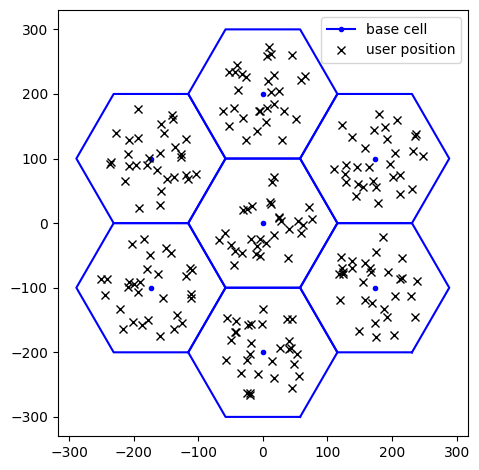

In [13]:
fig = sls.grid.show()
ax = fig.get_axes()
# Convert CUDA tensor to numpy for plotting
ut_loc_np = sls.ut_loc.cpu().numpy() if hasattr(sls.ut_loc, 'cpu') else sls.ut_loc
ax[0].plot(ut_loc_np[0, :, 0], ut_loc_np[0, :, 1],
           'xk', label='user position')
ax[0].legend()
plt.show()

We observe that:

- The base stations are placed on a hexagonal spiral grid with the defined
  number of rings;
- The inter-site distance depends on the chosen 3GPP scenario;
- Users are dropped uniformly at random within each sector, within the maximum
  distance from the respective base station. 

**Remark**: Hand-over procedures are **not**
implemented in this notebook; users simply attach to the nearest base station.  
As a result, user located near the cell edge may experience high interference.  
To mitigate this, the parameter `max_bs_ut_dist` can be adjusted to limit the
maximum distance between a user and its serving base station.

### Layer-2 parameters

Next, we define the parameters associated with the link
adaptation and power control modules, such as:
- BLER target, typically set to 10%;
- `olla_delta_up`, which determines how quickly outer-loop link
  adaptation (OLLA) adjusts the MCS index to the varying channel conditions;
- `(alpha_ul,p0_dbm_ul)`, defining the
  pathloss compensation factor and the target received power at the base
  station, respectively, in open-loop uplink power control;

as well as the number of slots to simulate.

In [14]:
# N. slots to simulate
num_slots = 1000

# Link Adaptation
# Note: bler_target and olla_delta_up must be Python floats (not tensors)
# to avoid graph breaks in torch.compile
bler_target = 0.1  # Must be in [0, 1]
olla_delta_up = 0.2

# Uplink power control parameters
# Pathloss compensation factor
alpha_ul = 1.0  # Must be in [0, 1]
# Target received power at the base station
p0_dbm_ul = -80.0  # [dBm]

### Simulation

We are now finally ready to run system-level simulations on the defined 3GPP
multicell scenario!

In [15]:
# System-level simulations
hist = sls(num_slots,
           alpha_ul,
           p0_dbm_ul,
           bler_target,
           olla_delta_up)

## Performance metric analysis

In this last section, we extract insights from simulations by analyzing the output data
at the user granularity. 

First, we average the relevant metrics across slots:

In [16]:
hist = clean_hist(hist)

# Average across slots and store in dictionary
results_avg = {
    'TBLER': (1 - np.nanmean(hist['harq'], axis=0)).flatten(),
    'MCS': np.nanmean(hist['mcs_index'], axis=0).flatten(),
    '# decoded bits / slot': np.nanmean(hist['num_decoded_bits'], axis=0).flatten(),
    'Effective SINR [dB]': 10*np.log10(np.nanmean(hist['sinr_eff'], axis=0).flatten()),
    'OLLA offset': np.nanmean(hist['olla_offset'], axis=0).flatten(),
    'TX power [dBm]': 10*np.log10(np.nanmean(hist['tx_power'], axis=0).flatten()) + 30,
    'Pathloss [dB]': 10*np.log10(np.nanmean(hist['pathloss_serving_cell'], axis=0).flatten()),
    '# allocated REs / slot': np.nanmean(hist['num_allocated_re'], axis=0).flatten(),
    'PF metric': np.nanmean(hist['pf_metric'], axis=0).flatten()
}
metrics = list(results_avg.keys())

### A bird's eye view

We now visualize the cumulative density function (CDF) of the selected
metrics, averaged across slots and computed per user, including:
- Transport block error rate (TBLER): Indicates how well link adaptation maintained it near the target value.
- MCS index;
- Number of decoded bits per slot;
- Effective SINR: Measures the channel quality for each user;
- Outer-loop link adaptation (OLLA) offset: Reflects the extent to which OLLA corrected the SINR estimation;
- Transmit power;
- Pathloss from the serving cell;
- Number of allocated resource elements (RE);
- Proportional fairness (PF) metric: A lower value indicates a fairer resource allocation across users.


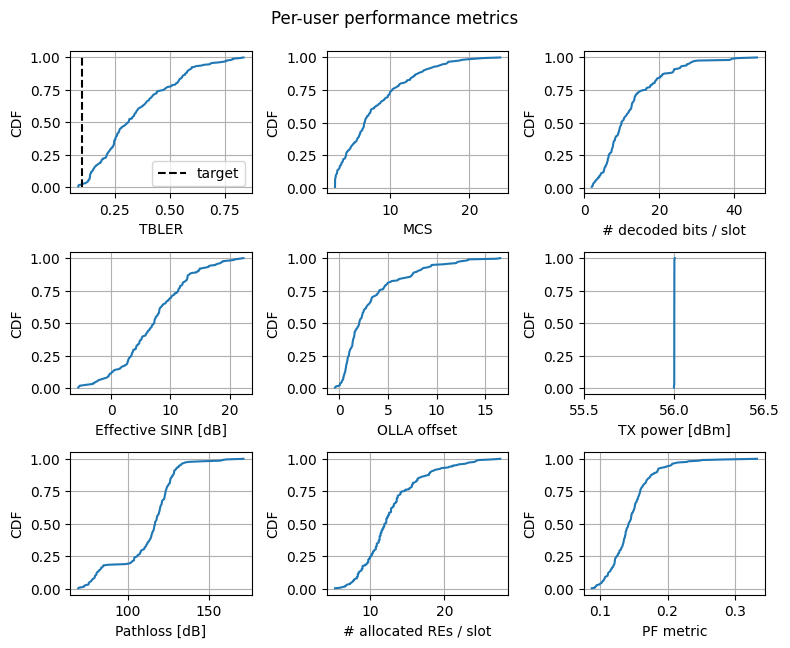

In [17]:
def get_cdf(values):
    """
    Computes the Cumulative Distribution Function (CDF) of the input
    """
    values = np.array(values).flatten()
    n = len(values)
    sorted_val = np.sort(values)
    cumulative_prob = np.arange(1, n+1) / n
    return sorted_val, cumulative_prob


fig, axs = plt.subplots(3, 3, figsize=(8, 6.5))
fig.suptitle('Per-user performance metrics', y=.99)

# Convert bler_target to scalar if it's a tensor
bler_target_val = bler_target.item() if hasattr(bler_target, 'item') else float(bler_target)

for ii in range(3):
    for jj in range(3):
        ax = axs[ii, jj]
        metric = metrics[3*ii+jj]
        ax.plot(*get_cdf(results_avg[metric]))
        if metric == 'TBLER':
            # Visualize BLER target
            ax.plot([bler_target_val]*2, [0, 1], '--k', label='target')
            ax.legend()
        if metric == 'TX power [dBm]':
            # Avoid plotting artifacts
            ax.set_xlim(ax.get_xlim()[0]-.5, ax.get_xlim()[1]+.5)
        ax.set_xlabel(metric)
        ax.grid()
        ax.set_ylabel('CDF')

fig.tight_layout()
plt.show()

We note that:

- For simulations in the downlink (`direction = downlink`), the transmit power per user remains constant and equals the
  base station's maximum transmit power.  
  This occurs because in the `SionnaSYS`
  block we chose, for simplicity, to feed the scheduler with a uniform
  achievable rate across subcarriers, resulting in only one user being scheduled
  per slot; 
- For uplink (`direction = uplink`), power varies significantly across users to compensate for the pathloss
  through the open-loop procedure. 

### MCS, SINR, and throughput

We next investigate the pairwise relationship among Modulation and Coding
Scheme (MCS), effective SINR, and throughput.

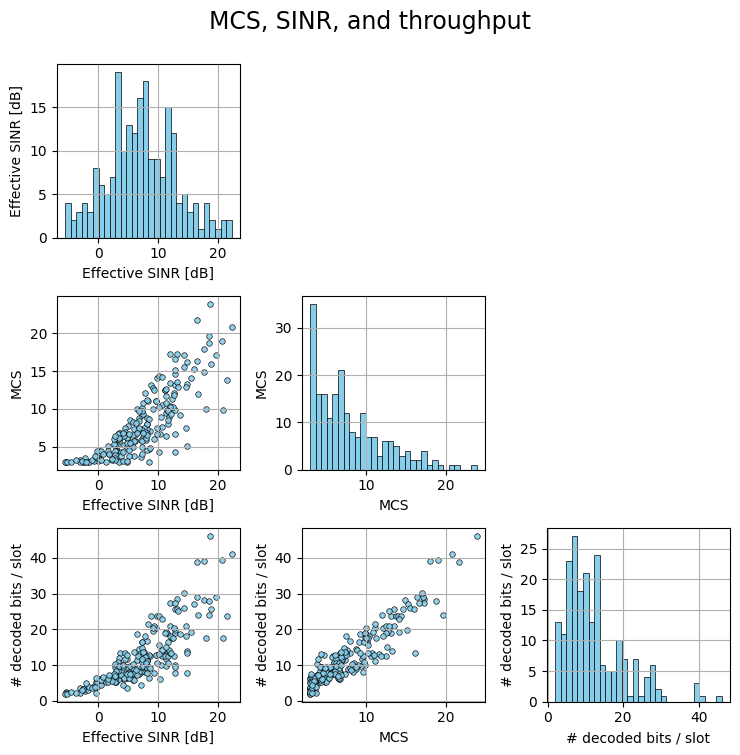

In [18]:
def pairplot(dict, keys, suptitle=None, figsize=2.5):
    fig, axs = plt.subplots(len(keys), len(keys),
                            figsize=[len(keys)*figsize]*2)
    for row, key_row in enumerate(keys):
        for col, key_col in enumerate(keys):
            ax = axs[row, col]
            ax.grid()
            if row == col:
                ax.hist(dict[key_row], bins=30,
                        color='skyblue', edgecolor='k',
                        linewidth=.5)
            elif col > row:
                fig.delaxes(ax)
            else:
                ax.scatter(dict[key_col], dict[key_row],
                           s=16, color='skyblue', alpha=0.9,
                           linewidths=.5, edgecolor='k')
            ax.set_ylabel(key_row)
            ax.set_xlabel(key_col)
    if suptitle is not None:
        fig.suptitle(suptitle, y=1, fontsize=17)
    fig.tight_layout()
    return fig, axs


fig, axs = pairplot(results_avg,
                    ['Effective SINR [dB]', 'MCS', '# decoded bits / slot'],
                    suptitle='MCS, SINR, and throughput')
plt.show()

As expected, as the SINR increases, higher MCS indices are used, resulting in higher throughput.

### Link adaptation

To main goal of link adaptation (LA) is to adapt the modulation and coding scheme
(MCS), thereby the transmission speed and reliability, to the evolving channel
conditions.

LA addresses this problem by maintaining the transport block error
rate (TBLER) around a pre-defined target, e.g., 10%, whenever possible.  

Since LA must deal with potentially outdated and noisy channel condition
feedback, it corrects the estimated SINR by applying an offset through a
feedback loop, known as outer-loop LA (OLLA).  
For more details on OLLA, please see [this notebook](https://nvlabs.github.io/sionna/sys/tutorials/notebooks/LinkAdaptation.html).

Below we visualize the relationship among the TBLER, MCS index, and OLLA offset.

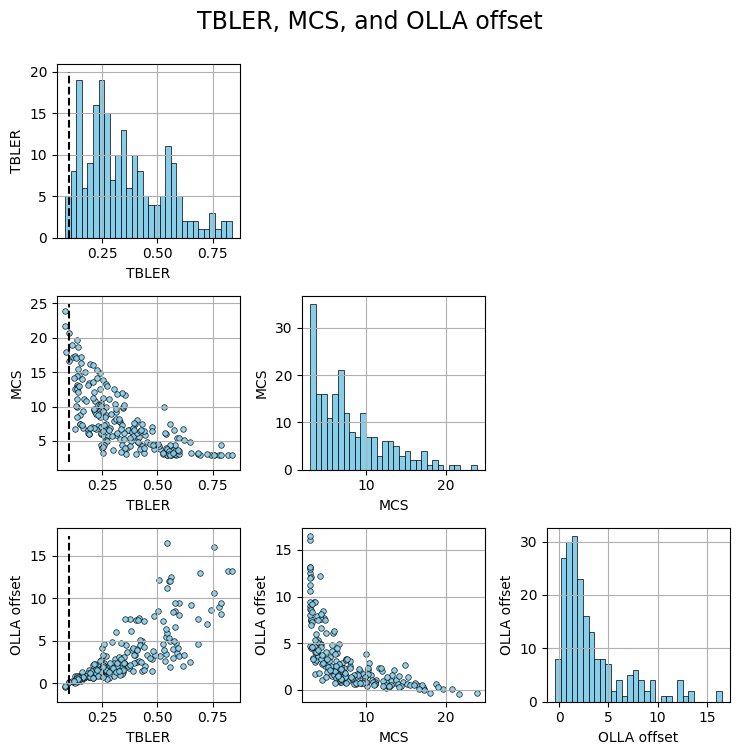

In [19]:
fig, axs = pairplot(results_avg,
                    ['TBLER', 'MCS', 'OLLA offset'],
                    suptitle='TBLER, MCS, and OLLA offset')
for ii in range(3):
    axs[ii, 0].plot([bler_target]*2, axs[ii, 0].get_ylim(), '--k')
plt.show()

From the MCS vs. TBLER figure we observe that the TBLER of users with low MCS
index, i.e., in bad channel conditions, is far from the target. This occurs
since at low MCS values, further spectral efficiency reduction is not feasible,
making it impossible to maintain the BLER at the target. For such users, the
OLLA offset tries to over-compensate, unsuccessfully, the estimated SINR (see offset vs. MCS figure).  

### Scheduler

The main principles of proportional fairness (PF) scheduling are to 
- Distribute the available time/frequency resources uniformly across users;
- Schedule users when their channel quality is high, relatively to their past average.

The scheduler assigns a resource to the user with the highest PF metric, which
is defined as the ratio between the achievable rate and the achieved throughput.  
An effective PF scheduler ensures that this metric remains low across all users.

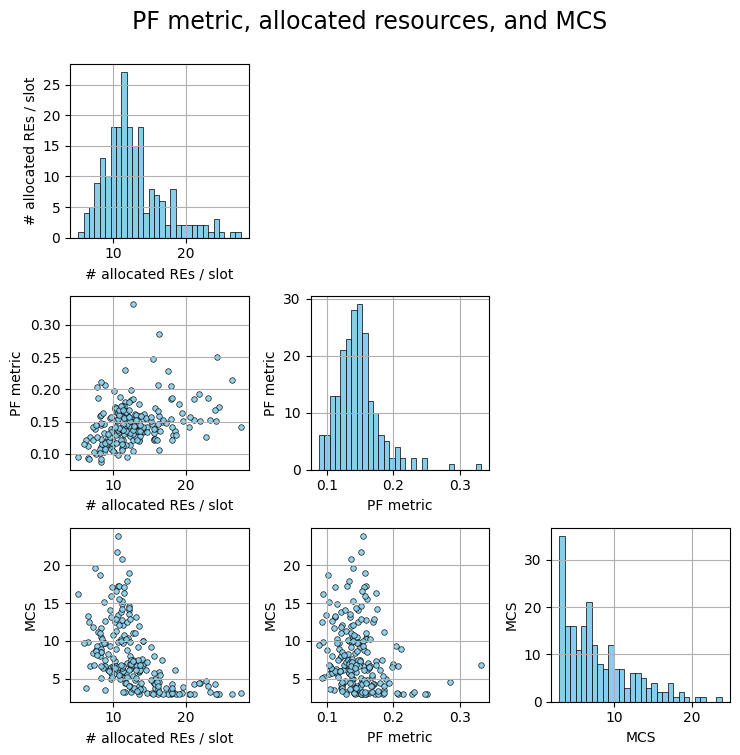

In [20]:
fig, axs = pairplot(results_avg,
                    ['# allocated REs / slot', 'PF metric', 'MCS'],
                    suptitle='PF metric, allocated resources, and MCS')
plt.show()

## Conclusions

Sionna SYS enables large-scale system-level simulations using
3GPP-compliant channel models generated via Sionna PHY.

We demonstrated how to integrate key SYS modules, including multicell
topology generation, phyisical layer abstraction, and layer-2 functionalities
such as link adaptation, scheduling, and power control.

To simplify the implementation, we assume *perfect* channel estimation and *exclude* handover management.

For a more straightforward example of assembling the SYS modules together with
ray-traced channels, we refer to the
[Sionna SYS meets RT notebook](https://nvlabs.github.io/sionna/sys/tutorials/notebooks/SYS_Meets_RT.html).